# ÉTAPE 4 — Customer Analytics : RFM Segmentation

Cette étape est très importante car elle transforme ton analyse d’un simple dashboard de ventes vers une vraie analyse comportementale client.

#### 1. Charger le dataset propre

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/master_orders_features.csv")

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

#### 2. Définir la date de référence

In [3]:
analysis_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
analysis_date

Timestamp('2018-10-18 17:30:18')

#### 3. Construire la table RFM

In [4]:
rfm = df.groupby("customer_unique_id").agg(
    
    Recency = (
        "order_purchase_timestamp",
        lambda x: (analysis_date - x.max()).days
    ),
    
    Frequency = (
        "order_id",
        "nunique"
    ),
    
    Monetary = (
        "net_revenue",
        "sum"
    )
    
).reset_index()

#### 4. Vérification rapide

In [6]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


#### 5. Statistiques RFM

In [7]:
rfm.describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,213.023712
std,153.414676,0.214384,640.917083
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.990000
50%,269.000000,1.000000,113.150000
75%,398.000000,1.000000,202.732500
max,773.000000,17.000000,109312.640000


#### 6. Création des scores RFM

Recency

In [8]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

Frequency

In [9]:
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

Monetary

In [10]:
rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

#### 7. Score global

In [11]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

#### 8. Segmentation clients

In [17]:
def segment(row):

    if row["R_score"] == 5 and row["F_score"] == 5:
        return "Champions"

    elif row["F_score"] in [4,5]:
        return "Loyal Customers"

    elif row["R_score"] in [1,2]:
        return "At Risk"

    else:
        return "Regular"


rfm["Segment"] = rfm.apply(segment, axis=1)

#### 9. Analyse des segments

In [18]:
rfm[["R_score","F_score","M_score"]].dtypes

R_score    category
F_score    category
M_score    category
dtype: object

Distribution clients :

In [19]:
rfm["Segment"].value_counts()

Segment
Regular            34513
Loyal Customers    34485
At Risk            23145
Champions           3953
Name: count, dtype: int64

Revenus par segment :

In [20]:
rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

Segment
Loyal Customers    7555418.99
Regular            6913189.74
At Risk            4967585.42
Champions          1034532.51
Name: Monetary, dtype: float64

Nombre de clients par segment :

In [21]:
rfm.groupby("Segment")["customer_unique_id"].count()

Segment
At Risk            23145
Champions           3953
Loyal Customers    34485
Regular            34513
Name: customer_unique_id, dtype: int64

In [24]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414,Regular
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,Regular
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,At Risk
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214,At Risk


#### 10. Visualisation

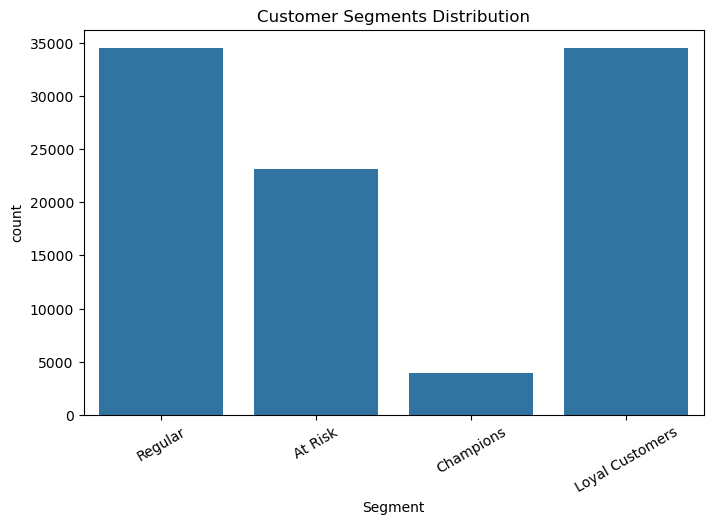

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Segment"
)

plt.title("Customer Segments Distribution")
plt.xticks(rotation=30)
plt.show()

#### 11. Visualisation 2 — Revenue Contribution by Segment

Quels segments de clients apportent le plus de chiffre d'affaires ?

In [25]:
revenue_segment = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_segment

,Segment,Monetary
0,Loyal Customers,7555418.99
1,Regular,6913189.74
2,At Risk,4967585.42
3,Champions,1034532.51


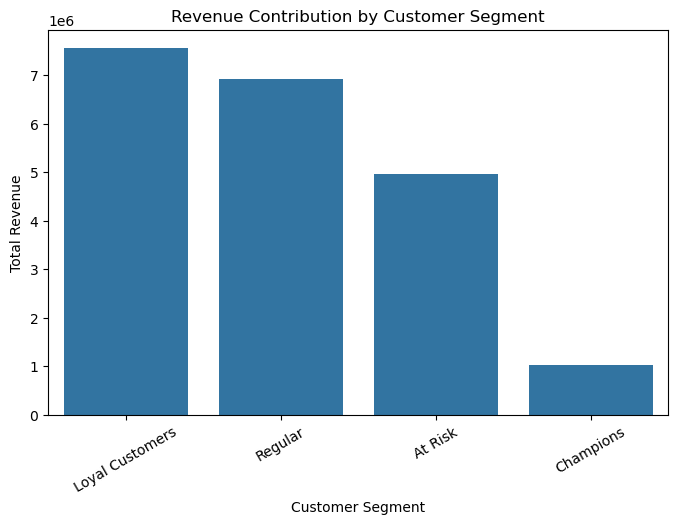

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_segment,
    x="Segment",
    y="Monetary"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.show()

Although Loyal Customers generate the highest total revenue, this does not mean they are the most valuable individually. This segment is large in volume, which explains its dominance in total revenue contribution. Champions, while smaller in number, still represent a high-value strategic group that should be prioritized for retention and loyalty programs.

#### 12. Visualisation 3 — Average Customer Value by Segment

Quel segment contient les clients qui dépensent le plus en moyenne ?

In [27]:
avg_value_segment = (
    rfm.groupby("Segment")["Monetary"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_value_segment

,Segment,Monetary
0,Champions,261.708199
1,Loyal Customers,219.092910
2,At Risk,214.628880
3,Regular,200.306833


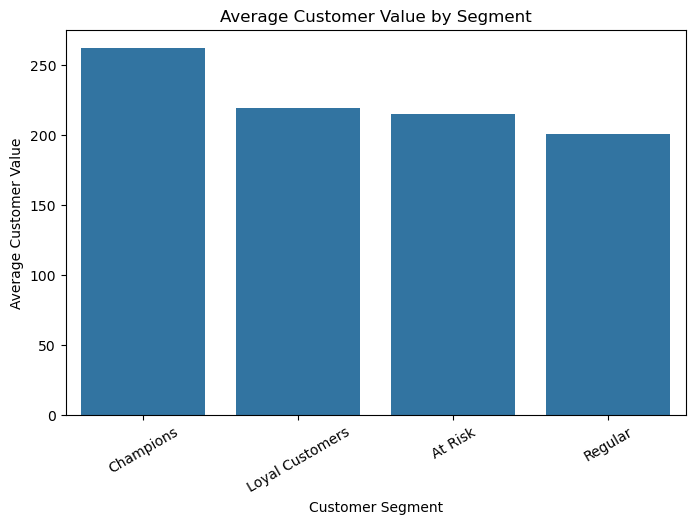

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_value_segment,
    x="Segment",
    y="Monetary"
)

plt.title("Average Customer Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Customer Value")

plt.xticks(rotation=30)

plt.show()

Champions customers have the highest average customer value, indicating that they spend significantly more per customer compared to other segments. This confirms that they are the most profitable group on a per-customer basis. Regular customers show the lowest value, suggesting a potential opportunity to increase engagement and upselling strategies.

sauvegarde du RFM

In [29]:
rfm.to_csv(
    "../data/processed/rfm_segments.csv",
    index=False
)